In [1]:
import pandas as pd

cols = ["id",
        "orig_time",
        "time",
        "status_time",
        "FICO_orig_time",
        "LTV_orig_time",
        "Interest_Rate_orig_time", 
        "balance_orig_time",
        "hpi_orig_time"]

df = pd.read_csv("mortgage.csv", usecols=cols)

In [2]:

# ORDENAR Y CORTAR EN EL PRIMER EVENTO TERMINAL

df = df.sort_values(["id", "time"]).copy()

# Default o payoff = estado terminal
df["is_terminal"] = df["status_time"].isin([1, 2])

# Identificar si ya ocurrió un terminal previamente
df["prior_terminal"] = (
    df.groupby("id")["is_terminal"]
      .shift(1)
      .fillna(False)
      .astype("int8")
)

df["cum_prior_terminal"] = (
    df.groupby("id")["prior_terminal"]
      .cumsum()
)

# Conservar todo hasta la primera fila terminal inclusive
df = df[
    df["cum_prior_terminal"] == 0
].copy()


# UNA FILA POR INDIVIDUO


df_cox = (
    df.groupby("id", as_index=False)
      .last()
)

print("Filas originales consideradas:", len(df))
print("Cantidad de IDs únicos:", df["id"].nunique())
print("Filas después:", len(df_cox))

print("\nDistribución de status_time:")
print(df_cox["status_time"].value_counts())

Filas originales consideradas: 622485
Cantidad de IDs únicos: 50000
Filas después: 50000

Distribución de status_time:
status_time
2    26589
1    15154
0     8257
Name: count, dtype: int64


In [3]:
df_cox["duration"] = df_cox["time"] - df_cox["orig_time"]

#analizo si hay tiempo negativo o cero, no tiene sentido en este contexto
print((df_cox["duration"] <= 0).sum())
df_cox = df_cox[df_cox["duration"] > 0].copy()

# Ahora creo la variable de evento, que es 1 si el status_time es 1 (default) y 0 si es 0 o 2 (no default o payoff)

df_cox["event"] = (df_cox["status_time"] == 1).astype(int)

print(df_cox["event"].value_counts())
print(df_cox["event"].mean())  # tasa de default

763
event
0    34173
1    15064
Name: count, dtype: int64
0.3059487783577391


In [4]:
cols_modelo = [
    "duration",
    "event",
    "balance_orig_time",
    "FICO_orig_time",
    "LTV_orig_time",
    "Interest_Rate_orig_time",
    "hpi_orig_time",
]
df_model = df_cox[cols_modelo].copy()

In [5]:
df_model["FICO_orig_time"] = df_model["FICO_orig_time"] / 10
df_model["LTV_orig_time"] = df_model["LTV_orig_time"] / 10
df_model["balance_orig_time"] = df_model["balance_orig_time"] / 100000

In [6]:
print(df_model.isnull().sum())
df_model = df_model.dropna().copy()

duration                   0
event                      0
balance_orig_time          0
FICO_orig_time             0
LTV_orig_time              0
Interest_Rate_orig_time    0
hpi_orig_time              0
dtype: int64


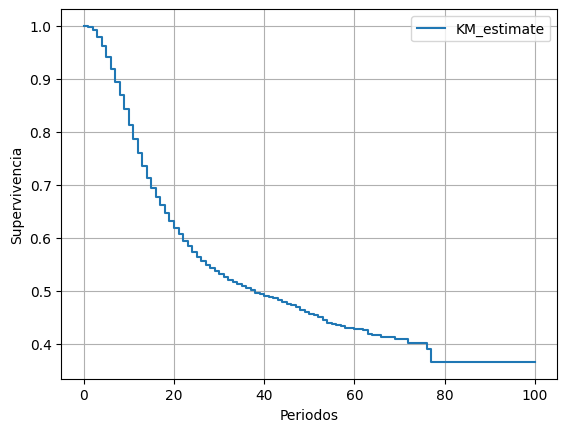

In [7]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

kmf.fit(durations=df_model["duration"], event_observed=df_model["event"])

kmf.plot_survival_function(ci_show=False)
plt.xlabel("Periodos")
plt.ylabel("Supervivencia")
plt.grid(True)

In [8]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

def km_por_variable(df, variable, nombre):
    df_temp = df.copy()
    kmf = KaplanMeierFitter()
    
    df_temp[f"grupo_{variable}"] = df_temp[variable] > df_temp[variable].median()
    
    plt.figure(figsize=(8,5))
    
    for grupo in df_temp[f"grupo_{variable}"].dropna().unique():
        mask = df_temp[f"grupo_{variable}"] == grupo
        label = "Alto" if grupo else "Bajo"
        
        kmf.fit(
            df_temp[mask]["duration"],
            df_temp[mask]["event"],
            label=label
        )
        kmf.plot_survival_function(ci_show=False)
    
    # Log-rank test
    grupo_alto = df_temp[df_temp[f"grupo_{variable}"] == True]
    grupo_bajo = df_temp[df_temp[f"grupo_{variable}"] == False]

    resultado = logrank_test(
        grupo_alto["duration"],
        grupo_bajo["duration"],
        event_observed_A=grupo_alto["event"],
        event_observed_B=grupo_bajo["event"]
    )

    plt.title(f"Kaplan-Meier por {nombre}")
    plt.xlabel("Periodos")
    plt.ylabel("Supervivencia")
    plt.grid(True)
    plt.show()
    
    print(f"p-value ({variable}):", resultado.p_value)

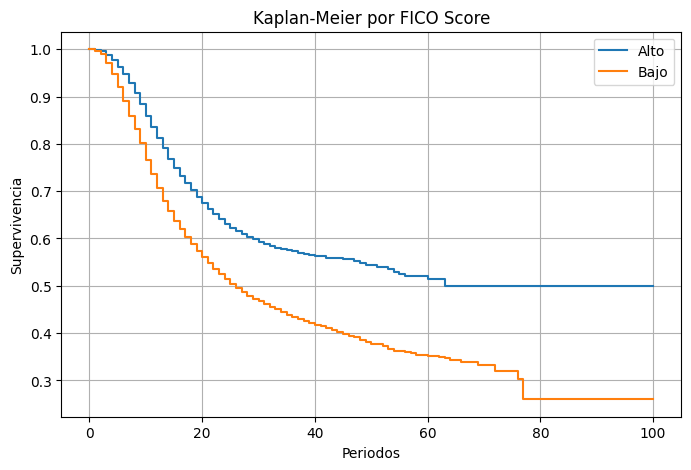

p-value (FICO_orig_time): 4.104760457118227e-168


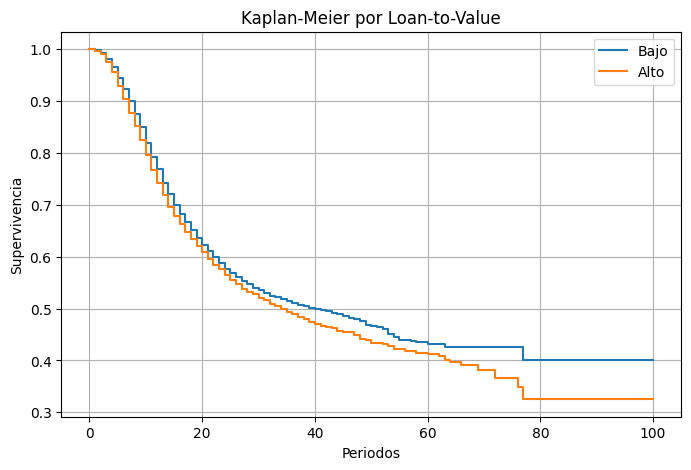

p-value (LTV_orig_time): 4.7572036944903227e-07


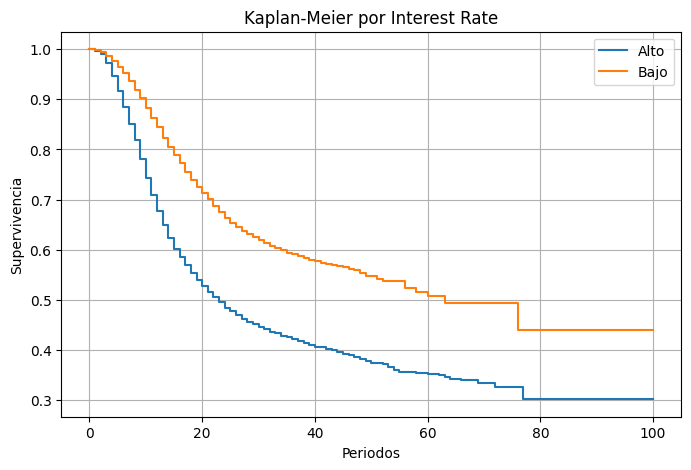

p-value (Interest_Rate_orig_time): 8.172095267857013e-305


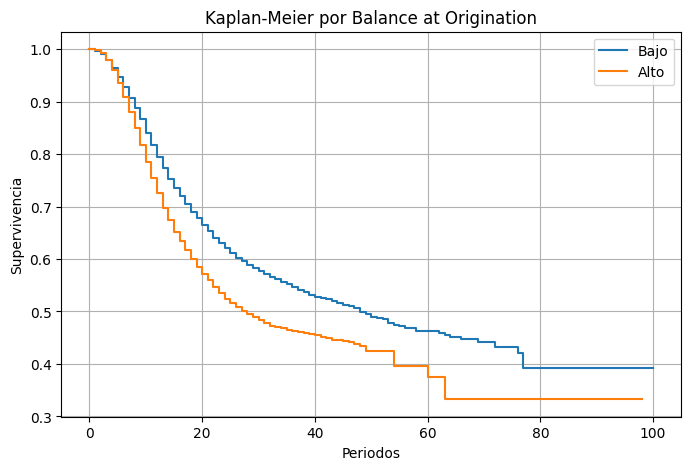

p-value (balance_orig_time): 5.107829626897548e-62


In [9]:
km_por_variable(df_model, "FICO_orig_time", "FICO Score")
km_por_variable(df_model, "LTV_orig_time", "Loan-to-Value")
km_por_variable(df_model, "Interest_Rate_orig_time", "Interest Rate")
km_por_variable(df_model, "balance_orig_time", "Balance at Origination")

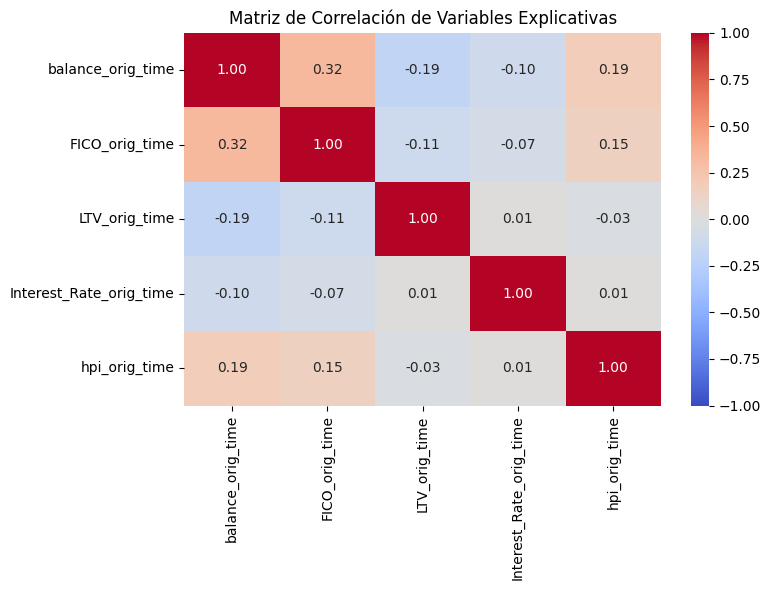


--- Factor de Inflación de la Varianza (VIF) ---
               Variable      VIF
      balance_orig_time 1.180980
         FICO_orig_time 1.130986
          hpi_orig_time 1.047539
          LTV_orig_time 1.040958
Interest_Rate_orig_time 1.013841


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Definimos las variables independientes
# (Excluimos explícitamente 'duration' y 'event' porque NO son predictoras)
cols_independientes = [
    "balance_orig_time",
    "FICO_orig_time",
    "LTV_orig_time",
    "Interest_Rate_orig_time",
    "hpi_orig_time"
]

X = df_model[cols_independientes].copy()


# PARTE A: MATRIZ DE CORRELACIÓN

plt.figure(figsize=(8, 6))
correlation_matrix = X.corr()

# Generamos un mapa de calor para verlo fácil
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Variables Explicativas")
plt.tight_layout()
plt.show()


# PARTE B: CÁLCULO DEL VIF (Variance Inflation Factor)


X_with_const = X.copy()
X_with_const.insert(0, 'constante', 1)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(1, X_with_const.shape[1])]

print("\n--- Factor de Inflación de la Varianza (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))

COX ESTATICO

In [11]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(df_model, duration_col="duration", event_col="event")

cph.print_summary(decimals=3)

<lifelines.CoxPHFitter: fitted with 49237 total observations, 34173 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 49237
number of events observed = 15064
   partial log-likelihood = -148586.137
         time fit was run = 2026-09-22 23:58:33 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
balance_orig_time        0.036     1.037     0.003           0.029           0.042               1.030               1.043
FICO_orig_time          -0.046     0.955     0.001          -0.048          -0.044               0.953               0.957
LTV_orig_time            0.174     1.190     0.008           0.158           0.191               1.171               1.210
Interest_Rate_orig_time  0.027     1.027     0.003           0.021           0.032               1.022               1.033
hpi_orig_time            0.018     1.018     0.000           0.018           0.019               1.018               1.019

                         cmp to       z       p  -log2(p)
covariate                                                
balance_orig_time         0.000  10.673 <0.0005    85.925
FICO_orig_time            0.000 -38.646 <0.0005       inf
LTV_orig_time             0.000  20.824 <0.0005   317.508
Interest_Rate_orig_time   0.000   9.744 <0.0005    72.116
hpi_orig_time             0.000  53.716 <0.0005       inf
---
Concordance = 0.696
Partial AIC = 297182.273
log-likelihood ratio test = 5720.465 on 5 df
-log2(p) of ll-ratio test = inf

In [12]:
cph.check_assumptions(df_model, p_value_threshold=0.05)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'balance_orig_time' failed the non-proportional test: p-value is 0.0003.

   Advice 1: the functional form of the variable 'balance_orig_time' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'balance_orig_time' using pd.cut, and then specify it in
`strata=['balance_orig_time', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'FICO_orig_time' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'FICO_orig_time' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation 

[]

Modelo CTV con evaluacion


In [13]:
import pandas as pd
import numpy as np

from lifelines import CoxTimeVaryingFitter
from sklearn.model_selection import train_test_split

from sksurv.util import Surv
from sksurv.metrics import cumulative_dynamic_auc, concordance_index_ipcw


# 1) CARGA Y ORDENAMIENTO


df = pd.read_csv("mortgage.csv")
df = df.sort_values(["id", "time"]).copy()


# 2) SELECCIÓN DE VARIABLES


cols = [
    "id", "time", "first_time", "status_time",
    "default_time", "payoff_time",
    "balance_time", "LTV_time", "interest_rate_time",
    "hpi_time", "gdp_time", "uer_time",
    "FICO_orig_time"
]

df = df[cols].copy()



# 3) TIEMPO RELATIVO Y FORMATO START-STOP


df["t_rel"] = df["time"] - df["first_time"] + 1
df["start"] = df.groupby("id")["t_rel"].shift(1).fillna(0)
df["stop"] = df["t_rel"]



# 4) IDENTIFICAR EVENTOS TERMINALES

# status_time = 1 -> default
# status_time = 2 -> payoff

# Se conserva la primera fila terminal y se eliminan
# todas las observaciones posteriores.


df["is_terminal"] = df["status_time"].isin([1, 2])

df["prior_terminal"] = (
    df.groupby("id")["is_terminal"]
      .shift(1)
      .fillna(False)
      .astype("int8")
)

df["cum_prior_terminal"] = df.groupby("id")["prior_terminal"].cumsum()
df = df[df["cum_prior_terminal"] == 0].copy()



# 5) IMPUTACIÓN FORWARD-FILL
#
# Se utiliza únicamente información previa del mismo
# individuo.


tv_vars = [
    "balance_time",
    "LTV_time",
    "interest_rate_time",
    "hpi_time",
    "gdp_time",
    "uer_time"
]

df[tv_vars] = df.groupby("id")[tv_vars].ffill()


# 6) REZAGO DE COVARIABLES TIME-VARYING

# Para cada intervalo se usa el valor observado en el
# período anterior.

# Para la primera observación de cada individuo se utiliza
# el primer valor disponible.


for col in tv_vars:
    df[f"{col}_lag"] = df.groupby("id")[col].shift(1)
    df[f"{col}_lag"] = df[f"{col}_lag"].fillna(df[col])



# 7) DEFINICIÓN DEL EVENTO

# Default = 1
# Payoff / fin de seguimiento = censura


df["event"] = (df["status_time"] == 1).astype(int)



# 8) VALIDACIONES DEL FORMATO TEMPORAL


df = df[df["stop"] > df["start"]].copy()
df = df.sort_values(["id", "start", "stop"]).copy()



# 9) REESCALADO DE VARIABLES

# Facilita estabilidad numérica e interpretación de HR.


df["balance_100k"] = df["balance_time_lag"] / 100000
df["LTV_10"] = df["LTV_time_lag"] / 10
df["rate_1"] = df["interest_rate_time_lag"]
df["gdp_1"] = df["gdp_time_lag"]
df["uer_1"] = df["uer_time_lag"]
df["FICO_10"] = df["FICO_orig_time"] / 10



# 10) ESPECIFICACIÓN DEL MODELO

# Modelo principal: sin HPI


USE_HPI = False

if USE_HPI:
    df["hpi_10"] = df["hpi_time_lag"] / 10

base_cols = [
    "id", "start", "stop", "event",
    "balance_100k", "LTV_10", "rate_1",
    "gdp_1", "uer_1", "FICO_10"
]

model_cols = base_cols + (["hpi_10"] if USE_HPI else [])
df_ctv = df[model_cols].dropna().copy()



# 11) TRAIN / TEST SPLIT POR INDIVIDUO

# Nunca se divide por filas.

# Esto evita que observaciones del mismo préstamo
# aparezcan simultáneamente en train y test.


id_event = (
    df_ctv.groupby("id", as_index=False)["event"]
          .max()
          .rename(columns={"event": "has_event"})
)

train_ids, test_ids = train_test_split(
    id_event["id"],
    test_size=0.30,
    random_state=42,
    stratify=id_event["has_event"]
)

train_df = df_ctv[df_ctv["id"].isin(train_ids)].copy()
test_df = df_ctv[df_ctv["id"].isin(test_ids)].copy()

print("\n===== SPLIT TRAIN / TEST =====")
print("Individuos train:", train_df["id"].nunique())
print("Individuos test :", test_df["id"].nunique())
print("Observaciones train:", len(train_df))
print("Observaciones test :", len(test_df))
print("Defaults train:", int(train_df.groupby("id")["event"].max().sum()))
print("Defaults test :", int(test_df.groupby("id")["event"].max().sum()))



# 12) ESTIMACIÓN DEL COX TIME-VARYING

# El modelo se ajusta ÚNICAMENTE en TRAIN.


ctv = CoxTimeVaryingFitter(penalizer=0.01)

ctv.fit(
    train_df,
    id_col="id",
    start_col="start",
    stop_col="stop",
    event_col="event",
    show_progress=True
)



# 13) RESULTADOS DEL MODELO


print("\n===== RESUMEN DEL MODELO =====")
ctv.print_summary()

summary = ctv.summary.copy()
summary["HR"] = np.exp(summary["coef"])
summary["HR_inf"] = np.exp(summary["coef lower 95%"])
summary["HR_sup"] = np.exp(summary["coef upper 95%"])

hr_table = summary[
    ["coef", "se(coef)", "p", "HR", "HR_inf", "HR_sup"]
].sort_values("HR", ascending=False)

print("\n===== HAZARD RATIOS =====")
print(hr_table)



# 14) OUTCOME FINAL POR INDIVIDUO

# Necesario para la evaluación fuera de muestra.


outcomes = (
    df.sort_values(["id", "stop"])
      .groupby("id", as_index=False)
      .agg(
          final_time=("stop", "max"),
          final_event=("event", "max")
      )
)



# 15) FUNCIÓN DE EVALUACIÓN LANDMARK

# Ejemplo:

# landmark = 12
# horizon = 12

# Se evalúa entre quienes continúan bajo riesgo
# después del mes 12 qué tan bien discrimina el
# modelo los defaults de los próximos 12 meses.


def evaluar_landmark(
    df,
    outcomes,
    ctv,
    train_ids,
    test_ids,
    landmark,
    horizon=12,
    use_hpi=False
):

    
    # A) Individuos bajo riesgo en el landmark
   

    at_risk_ids = outcomes.loc[
        outcomes["final_time"] > landmark,
        "id"
    ]

    
    # B) Última información disponible hasta el landmark
    

    snapshot = (
        df[
            (df["id"].isin(at_risk_ids)) &
            (df["t_rel"] <= landmark)
        ]
        .sort_values(["id", "t_rel"])
        .groupby("id", as_index=False)
        .tail(1)
        .copy()
    )

    
    # C) Variables conocidas al momento de predicción
    
    # Ahora sí utilizamos la información observada en el
    # landmark para predecir lo que ocurre DESPUÉS.
    

    snapshot["balance_100k"] = snapshot["balance_time"] / 100000
    snapshot["LTV_10"] = snapshot["LTV_time"] / 10
    snapshot["rate_1"] = snapshot["interest_rate_time"]
    snapshot["gdp_1"] = snapshot["gdp_time"]
    snapshot["uer_1"] = snapshot["uer_time"]
    snapshot["FICO_10"] = snapshot["FICO_orig_time"] / 10

    covariates = [
        "balance_100k",
        "LTV_10",
        "rate_1",
        "gdp_1",
        "uer_1",
        "FICO_10"
    ]

    if use_hpi:
        snapshot["hpi_10"] = snapshot["hpi_time"] / 10
        covariates.append("hpi_10")

   
    # D) Eliminar casos sin información necesaria
    

    snapshot = snapshot.dropna(subset=covariates).copy()

    
    # E) Score de riesgo estimado por el CTV
    
    # Mayor score = mayor riesgo relativo.
    

    snapshot["risk_score"] = (
        ctv.predict_partial_hazard(snapshot[covariates]).to_numpy()
    )

    
    # F) Agregar outcome observado
    
    snapshot = snapshot.merge(outcomes, on="id", how="inner")

    snapshot["remaining_time"] = snapshot["final_time"] - landmark
    snapshot["remaining_event"] = snapshot["final_event"].astype(bool)

    
    # G) Mantener el mismo split utilizado al entrenar
    

    train_eval = snapshot[snapshot["id"].isin(train_ids)].copy()
    test_eval = snapshot[snapshot["id"].isin(test_ids)].copy()

    
    # H) Información descriptiva
    

    defaults_horizon = int(
        (
            test_eval["remaining_event"] &
            (test_eval["remaining_time"] <= horizon)
        ).sum()
    )

    censurados_horizon = int(
        (
            (~test_eval["remaining_event"]) &
            (test_eval["remaining_time"] < horizon)
        ).sum()
    )

    n_test = len(test_eval)

    prop_defaults = defaults_horizon / n_test if n_test > 0 else np.nan
    prop_censura = censurados_horizon / n_test if n_test > 0 else np.nan

    
    # I) Formato requerido por scikit-survival
    

    y_train = Surv.from_arrays(
        event=train_eval["remaining_event"].to_numpy(),
        time=train_eval["remaining_time"].to_numpy()
    )

    y_test = Surv.from_arrays(
        event=test_eval["remaining_event"].to_numpy(),
        time=test_eval["remaining_time"].to_numpy()
    )

    risk_test = test_eval["risk_score"].to_numpy()

    
    # J) AUC acumulativa / dinámica
    

    try:
        auc, _ = cumulative_dynamic_auc(
            y_train,
            y_test,
            risk_test,
            times=[horizon]
        )
        auc_dinamica = float(auc[0])

    except ValueError as error:
        print(f"\nAdvertencia AUC (landmark={landmark}): {error}")
        auc_dinamica = np.nan

    
    # K) C-index IPCW
    

    try:
        cindex_ipcw = float(
            concordance_index_ipcw(
                y_train,
                y_test,
                risk_test,
                tau=horizon
            )[0]
        )

    except ValueError as error:
        print(f"\nAdvertencia C-index (landmark={landmark}): {error}")
        cindex_ipcw = np.nan

    
    # L) Resultado del landmark
    

    return {
        "landmark": landmark,
        "horizonte": horizon,
        "n_train": len(train_eval),
        "n_test": n_test,
        "defaults_12m": defaults_horizon,
        "prop_defaults": prop_defaults,
        "censurados_antes_12m": censurados_horizon,
        "prop_censura": prop_censura,
        "AUC_dinamica": auc_dinamica,
        "C_index_IPCW": cindex_ipcw
    }



# 16) EVALUACIÓN DINÁMICA

# Se utilizan únicamente landmarks 12 y 24.

# El landmark 36 se excluye del análisis principal debido
# al número extremadamente reducido de eventos y al alto
# grado de censura observado en el horizonte posterior.


LANDMARKS = [12, 24]
HORIZON = 12

resultados = []

for landmark in LANDMARKS:
    resultado = evaluar_landmark(
        df=df,
        outcomes=outcomes,
        ctv=ctv,
        train_ids=train_ids,
        test_ids=test_ids,
        landmark=landmark,
        horizon=HORIZON,
        use_hpi=USE_HPI
    )
    resultados.append(resultado)

resultados_df = pd.DataFrame(resultados)



# 17) FORMATO DE RESULTADOS


resultados_df["prop_defaults"] *= 100
resultados_df["prop_censura"] *= 100

resultados_df = resultados_df.rename(
    columns={
        "prop_defaults": "% defaults",
        "prop_censura": "% censura"
    }
)

print("\n===== EVALUACIÓN DINÁMICA DEL CTV =====")
print(resultados_df.round(4).to_string(index=False))


===== SPLIT TRAIN / TEST =====
Individuos train: 34987
Individuos test : 14995
Observaciones train: 434908
Observaciones test : 186972
Defaults train: 10604
Defaults test : 4545
Iteration 1: norm_delta = 4.27e-01, step_size = 0.9500, log_lik = -102323.31092, newton_decrement = 1.67e+03, seconds_since_start = 0.2
Iteration 2: norm_delta = 5.27e-02, step_size = 0.9500, log_lik = -102396.26485, newton_decrement = 9.71e+02, seconds_since_start = 0.4
Iteration 3: norm_delta = 3.79e-02, step_size = 0.9500, log_lik = -101246.54821, newton_decrement = 2.53e+02, seconds_since_start = 0.6
Iteration 4: norm_delta = 2.91e-02, step_size = 1.0000, log_lik = -100945.12575, newton_decrement = 6.37e+01, seconds_since_start = 0.8
Iteration 5: norm_delta = 1.38e-02, step_size = 1.0000, log_lik = -100870.04170, newton_decrement = 7.76e+00, seconds_since_start = 0.9
Iteration 6: norm_delta = 2.37e-03, step_size = 1.0000, log_lik = -100861.59676, newton_decrement = 1.73e-01, seconds_since_start = 1.1
Itera

<lifelines.CoxTimeVaryingFitter: fitted with 434908 periods, 34987 subjects, 10604 events>
         event col = 'event'
         penalizer = 0.01
number of subjects = 34987
 number of periods = 434908
  number of events = 10604
partial log-likelihood = -100861.42
  time fit was run = 2026-09-22 23:58:41 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
balance_100k  0.03      1.03      0.00            0.02            0.04                1.02                1.04
LTV_10        0.07      1.08      0.00            0.07            0.08                1.07                1.08
rate_1        0.09      1.10      0.00            0.08            0.10                1.09                1.10
gdp_1        -0.06      0.94      0.00           -0.07           -0.05                0.93                0.95
uer_1         0.02      1.02      0.01            0.01            0.03                1.01                1.03
FICO_10      -0.03      0.97      0.00           -0.03           -0.03                0.97                0.97

              cmp to      z      p  -log2(p)
covariate                                   
balance_100k    0.00   9.20 <0.005     64.53
LTV_10          0.00  44.87 <0.005       inf
rate_1          0.00  22.64 <0.005    374.46
gdp_1           0.00 -14.54 <0.005    156.65
uer_1           0.00   3.78 <0.005     12.64
FICO_10         0.00 -25.38 <0.005    469.48
---
Partial AIC = 201734.84
log-likelihood ratio test = 2923.78 on 6 df
-log2(p) of ll-ratio test = inf


===== HAZARD RATIOS =====
                  coef  se(coef)              p        HR    HR_inf    HR_sup
covariate                                                                    
rate_1        0.090839  0.004013  1.895328e-113  1.095092  1.086513  1.103740
LTV_10        0.073208  0.001632   0.000000e+00  1.075954  1.072519  1.079400
balance_100k  0.030639  0.003332   3.749484e-20  1.031113  1.024401  1.037870
uer_1         0.021086  0.005578   1.565607e-04  1.021310  1.010206  1.032537
FICO_10      -0.030448  0.001200  4.702244e-142  0.970010  0.967732  0.972294
gdp_1        -0.062478  0.004298   6.990953e-48  0.939434  0.931554  0.947381

===== EVALUACIÓN DINÁMICA DEL CTV =====
 landmark  horizonte  n_train  n_test  defaults_12m  % defaults  censurados_antes_12m  % censura  AUC_dinamica  C_index_IPCW
       12         12    11501    4944          1176     23.7864                   908    18.3657        0.6354        0.6358
       24         12     6485    2807           269      9

Modelo de Regresion Logistica

In [14]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report


# LOGIT A HORIZONTE FIJO
# Landmark = 12 meses
# Horizonte = próximos 12 meses


LANDMARK_LOGIT = 12
HORIZON_LOGIT = 12



# 1) OUTCOME FINAL POR INDIVIDUO


outcomes_logit = (
    df.sort_values(["id", "stop"])
      .groupby("id", as_index=False)
      .agg(
          final_time=("stop", "max"),
          final_event=("event", "max")
      )
)



# 2) INDIVIDUOS ACTIVOS AL LANDMARK


at_risk_ids = outcomes_logit.loc[
    outcomes_logit["final_time"] > LANDMARK_LOGIT,
    "id"
]



# 3) SNAPSHOT DE INFORMACIÓN DISPONIBLE AL MES 12


logit_df = (
    df[
        (df["id"].isin(at_risk_ids)) &
        (df["t_rel"] <= LANDMARK_LOGIT)
    ]
    .sort_values(["id", "t_rel"])
    .groupby("id", as_index=False)
    .tail(1)
    .copy()
)



# 4) VARIABLES EXPLICATIVAS
# Mismas variables utilizadas en la evaluación del CTV


logit_df["balance_100k"] = logit_df["balance_time"] / 100000
logit_df["LTV_10"] = logit_df["LTV_time"] / 10
logit_df["rate_1"] = logit_df["interest_rate_time"]
logit_df["gdp_1"] = logit_df["gdp_time"]
logit_df["uer_1"] = logit_df["uer_time"]
logit_df["FICO_10"] = logit_df["FICO_orig_time"] / 10

features = [
    "balance_100k",
    "LTV_10",
    "rate_1",
    "gdp_1",
    "uer_1",
    "FICO_10"
]

logit_df = logit_df.dropna(subset=features).copy()



# 5) AGREGAR OUTCOME FINAL


logit_df = logit_df.merge(
    outcomes_logit,
    on="id",
    how="inner"
)

logit_df["remaining_time"] = (
    logit_df["final_time"] - LANDMARK_LOGIT
)



# 6) CONSTRUCCIÓN DEL TARGET A 12 MESES

# 1 = default dentro de los próximos 12 meses

# 0 = observado sin default hasta al menos el final
#     del horizonte de 12 meses

# Censurado antes de completar el horizonte:
#     se excluye porque no conocemos su resultado a 12 meses.


default_12m = (
    (logit_df["final_event"] == 1) &
    (logit_df["remaining_time"] <= HORIZON_LOGIT)
)

known_nondefault_12m = (
    (logit_df["remaining_time"] >= HORIZON_LOGIT) &
    (~default_12m)
)

logit_df["target_12m"] = np.nan

logit_df.loc[
    known_nondefault_12m,
    "target_12m"
] = 0

logit_df.loc[
    default_12m,
    "target_12m"
] = 1


# Cantidad antes de eliminar los censurados
n_antes = len(logit_df)

# Excluir casos cuyo outcome a 12 meses es desconocido
logit_df = logit_df.dropna(
    subset=["target_12m"]
).copy()

logit_df["target_12m"] = (
    logit_df["target_12m"].astype(int)
)

print("\n===== CONSTRUCCIÓN DEL TARGET =====")
print("Observaciones iniciales:", n_antes)
print("Observaciones utilizables:", len(logit_df))
print("Excluidos por censura:", n_antes - len(logit_df))
print(
    "Defaults próximos 12m:",
    int(logit_df["target_12m"].sum())
)
print(
    "Tasa de default:",
    round(logit_df["target_12m"].mean(), 4)
)



# 7) MISMO SPLIT POR ID UTILIZADO EN EL CTV


train_logit = logit_df[
    logit_df["id"].isin(train_ids)
].copy()

test_logit = logit_df[
    logit_df["id"].isin(test_ids)
].copy()

X_train = train_logit[features]
y_train = train_logit["target_12m"]

X_test = test_logit[features]
y_test = test_logit["target_12m"]

print("\n===== SPLIT LOGIT =====")
print("Train:", len(train_logit))
print("Test :", len(test_logit))
print("Defaults train:", int(y_train.sum()))
print("Defaults test :", int(y_test.sum()))
print(
    "Default rate train:",
    round(y_train.mean(), 4)
)
print(
    "Default rate test :",
    round(y_test.mean(), 4)
)



# 8) AJUSTE DEL MODELO
# Logit sin regularización


logit = LogisticRegression(
    C=np.inf,
    solver="lbfgs",
    max_iter=2000
)

logit.fit(X_train, y_train)



# 9) PROBABILIDADES Y AUC


prob_train = logit.predict_proba(X_train)[:, 1]
prob_test = logit.predict_proba(X_test)[:, 1]

auc_train = roc_auc_score(
    y_train,
    prob_train
)

auc_test = roc_auc_score(
    y_test,
    prob_test
)

print("\n===== AUC LOGIT =====")
print(f"AUC TRAIN: {auc_train:.4f}")
print(f"AUC TEST : {auc_test:.4f}")


===== CONSTRUCCIÓN DEL TARGET =====
Observaciones iniciales: 16445
Observaciones utilizables: 13370
Excluidos por censura: 3075
Defaults próximos 12m: 3918
Tasa de default: 0.293

===== SPLIT LOGIT =====
Train: 9334
Test : 4036
Defaults train: 2742
Defaults test : 1176
Default rate train: 0.2938
Default rate test : 0.2914

===== AUC LOGIT =====
AUC TRAIN: 0.6537
AUC TEST : 0.6503


In [15]:

# 10) Odds Ratios


coef_table = pd.DataFrame({
    "variable": features,
    "coef": logit.coef_[0],
    "OR": np.exp(logit.coef_[0])
}).sort_values("OR", ascending=False)

print("\n===== ODDS RATIOS =====")
print(coef_table.to_string(index=False))


# 11) Matriz de confusión
# Threshold 0.50 como análisis descriptivo


pred_test_05 = (prob_test >= 0.50).astype(int)

print("\n===== MATRIZ DE CONFUSIÓN (threshold = 0.50) =====")
print(confusion_matrix(y_test, pred_test_05))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, pred_test_05, digits=4))


===== ODDS RATIOS =====
    variable      coef       OR
      LTV_10  0.202012 1.223862
      rate_1  0.085294 1.089037
balance_100k  0.066629 1.068898
       gdp_1  0.011341 1.011406
       uer_1 -0.027751 0.972630
     FICO_10 -0.035863 0.964772

===== MATRIZ DE CONFUSIÓN (threshold = 0.50) =====
[[2736  124]
 [1109   67]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0     0.7116    0.9566    0.8161      2860
           1     0.3508    0.0570    0.0980      1176

    accuracy                         0.6945      4036
   macro avg     0.5312    0.5068    0.4571      4036
weighted avg     0.6064    0.6945    0.6069      4036



In [16]:

# COMPARACIÓN CTV vs LOGIT
# Landmark = 12 meses | Horizonte = 12 meses


ctv_12 = resultados_df[resultados_df["landmark"] == 12].iloc[0]

comparacion = pd.DataFrame({
    "Modelo": [
        "Cox Time-Varying",
        "Regresión Logística"
    ],
    "Landmark": [
        12,
        12
    ],
    "Horizonte": [
        12,
        12
    ],
    "N test": [
        int(ctv_12["n_test"]),
        len(test_logit)
    ],
    "Defaults test": [
        int(ctv_12["defaults_12m"]),
        int(y_test.sum())
    ],
    "AUC": [
        ctv_12["AUC_dinamica"],
        auc_test
    ],
    "Tratamiento censura": [
        "IPCW",
        "Excluye censurados antes del horizonte"
    ]
})

print("\n===== COMPARACIÓN CTV vs LOGIT =====")
print(comparacion.round(4).to_string(index=False))

print(
    "\nC-index IPCW del CTV (landmark 12):",
    round(ctv_12["C_index_IPCW"], 4)
)


===== COMPARACIÓN CTV vs LOGIT =====
             Modelo  Landmark  Horizonte  N test  Defaults test    AUC                    Tratamiento censura
   Cox Time-Varying        12         12    4944           1176 0.6354                                   IPCW
Regresión Logística        12         12    4036           1176 0.6503 Excluye censurados antes del horizonte

C-index IPCW del CTV (landmark 12): 0.6358
